In [5]:
%matplotlin inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')
import numpy as np


UsageError: Line magic function `%matplotlin` not found.


Text(0.5, 1.0, 'visualization of Hog features')

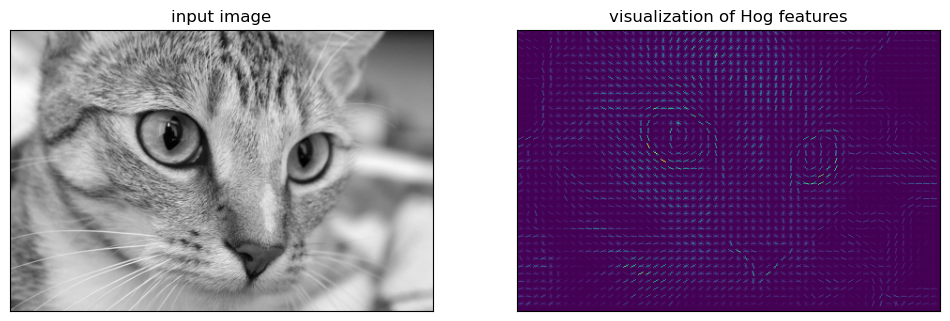

In [6]:
import matplotlib.pyplot as plt

from skimage import data,color,feature
import skimage.data

image = color.rgb2gray(data.chelsea())
hog_vec,hog_vis = feature.hog(image,visualize = True)

fig,ax = plt.subplots(1,2,figsize = (12,6),subplot_kw=dict(xticks = [],yticks = []))
ax[0].imshow(image,cmap = 'gray')
ax[0].set_title('input image')

ax[1].imshow(hog_vis)
ax[1].set_title('visualization of Hog features')


In [7]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people()
positive_patches = faces.images
positive_patches.shape

(13233, 62, 47)

In [8]:
data.camera().shape

(512, 512)

In [9]:
from skimage import data,transform

imgs_to_use = ['camera','text','coins','moon','page','clock','immunohistochemistry','chelsea','coffee','hubble_deep_field']
raw_images = (getattr(data,name)() for name in imgs_to_use)
images = [color.rgb2gray(image) if image.ndim == 3 else image for image in raw_images]

In [10]:
import numpy as np
from sklearn.feature_extraction.image import PatchExtractor
def extract_patches(img,N,scale=1.0,patch_size = positive_patches[0].shape):
    extracted_patch_size = tuple((scale*np.array(patch_size)).astype(int))
    extractor = PatchExtractor(patch_size = extracted_patch_size,max_patches = N,random_state = 0)
    patches = extractor.transform(img[np.newaxis])
    if scale != 1:
        patches = np.array([transform.resize(patch,patch_size)
                           for patch in patches])
    return patches
negative_patches = np.vstack([extract_patches(im,1000,scale)
                             for im in images for scale in [0.5,1.0,2.0]])

negative_patches.shape

(30000, 62, 47)

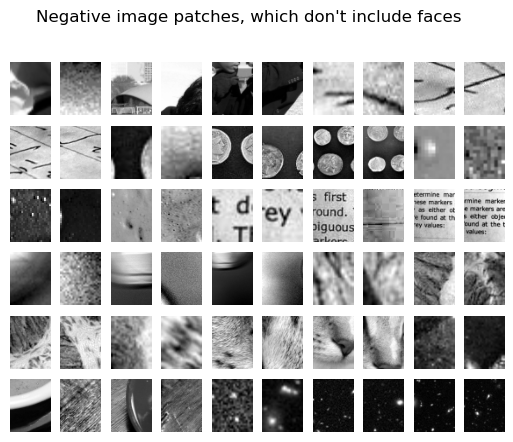

In [11]:
import matplotlib.pyplot as plt



fig , ax = plt.subplots(6,10)
plt.suptitle("Negative image patches, which don't include faces", y=0.99)
for i,axi in enumerate(ax.flat):
    axi.imshow(negative_patches[500*i],cmap = 'gray')
    axi.axis('off')

In [12]:
from itertools import chain
X_train = np.array([feature.hog(im)
                   for im in chain(positive_patches,negative_patches)])
y_train = np.zeros(X_train.shape[0])
y_train[:positive_patches.shape[0]] = 1


In [13]:
X_train.shape

(43233, 1215)

In [14]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score

cross_val_score(GaussianNB(),X_train,y_train)


array([0.95732624, 0.972476  , 0.97340118, 0.97628961, 0.97490169])

In [15]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
grid  = GridSearchCV(LinearSVC(),{'C':[1.0,2.0,4.0,8.0]})
grid.fit(X_train,y_train)
grid.best_score_

np.float64(0.988527272732623)

In [16]:
grid.best_params_

{'C': 2.0}

In [17]:
model=grid.best_estimator_
model.fit(X_train,y_train)

LinearSVC(C=2.0)

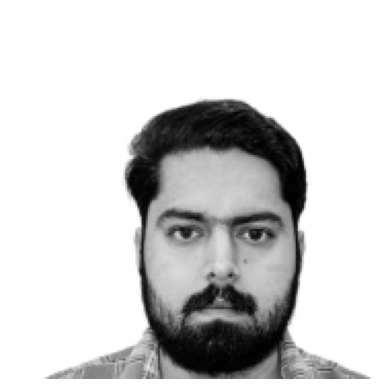

In [18]:

import skimage.io
from skimage import color

# Load your image
# Make sure the image is in the same folder as your script, or provide the full path
my_image = skimage.io.imread('my_photo.jpeg')

# HOG usually requires a grayscale image, so convert it if it's in color
test_image = color.rgb2gray(my_image)



#test_image = skimage.data.astronaut()
#test_image = skimage.color.rgb2gray(test_image)
test_image = skimage.transform.rescale(test_image,0.5)
test_image = test_image[:180,:180]

plt.imshow(test_image,cmap = 'gray')
plt.axis('off');

In [19]:
def sliding_window(img,patch_size=positive_patches[0].shape,
                  istep = 2,jstep = 2,scale = 1.0):
    Ni,Nj = (int(scale*s)for s in patch_size)
    for i in range(0,img.shape[0] - Ni,istep):
        for j in range(0,img.shape[1]-Ni,jstep):
            patch = img[i:i + Ni,j:j + Nj]
            if scale !=1:
                patch = transform.resize(patch,patch_size)
            yield(i,j),patch
indices,patches = zip(*sliding_window(test_image))
patches_hog = np.array([feature.hog(patch)for patch in patches])
patches_hog.shape

(3481, 1215)

In [20]:
labels = model.predict(patches_hog)
labels.sum()

np.float64(99.0)

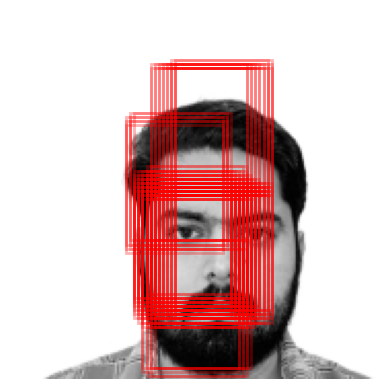

In [21]:
fig,ax = plt.subplots()
ax.imshow(test_image,cmap ='gray')
ax.axis('off')
Ni,Nj = positive_patches[0].shape
indices = np.array(indices)

for i,j in indices[labels ==1]:
    ax.add_patch(plt.Rectangle((j,i),Nj,Ni,edgecolor = 'red',alpha = 0.3,lw = 2,facecolor = 'none'))

In [ ]:
import joblib

joblib.dump(model, "face_model.pkl")

['face_model.pkl']